# Chronos-2 Covariate Smoke Test

This notebook is the repo's smallest practical Chronos-2 covariate baseline. It assumes a local project environment is already set up from the repo root with `requirements.txt` and that the notebook is running on the repo's `.venv` kernel.

The goal is deliberately narrow:

- verify the notebook is attached to the expected Python environment,
- load the `amazon/chronos-2` model through the supported Chronos dataframe API,
- run one covariate-aware forecast on the official `electricity_price` sample dataset,
- compare Chronos-2 against a simple seasonal naive baseline with visualization and standard metrics.

For the sample data, this notebook uses the **electricity_price** dataset from the Chronos documentation because it is both energy-related and the most direct public example of the `future_df` covariate interface. To keep the smoke test fast, the notebook forecasts only one series for the next 24 hourly steps.

Notes:

- The first model download is large and can take a few minutes.
- GPU is preferred for speed, but the notebook falls back to CPU when no supported accelerator is available.
- On Apple silicon, PyTorch acceleration uses `mps`, not `cuda`.
- The covariates in this example are future-known load and renewable generation forecasts supplied in `future_df`.


## Environment And Kernel Setup

Recommended repo setup from the project root:

```bash
python -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name energy-forecast-model --display-name "Python (.venv) energy-forecast-model"
```

Then in VS Code:

1. Open this notebook.
2. Click **Select Kernel**.
3. Choose the interpreter or Jupyter kernel backed by `/Users/epeng/code/personal/energy-forecast-model/.venv/bin/python`.

Chronos-2 requires **Python 3.10+**. For this repo, Python 3.11 is the recommended baseline.


In [1]:
from __future__ import annotations

import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from chronos import BaseChronosPipeline, Chronos2Pipeline

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)


In [2]:
print(f"Python executable: {sys.executable}")
print(f"Python version:    {sys.version.split()[0]}")
print(f"Platform:          {platform.platform()}")
print(f"Torch version:     {torch.__version__}")


Python executable: /Users/epeng/code/personal/energy-forecast-model/.venv/bin/python3
Python version:    3.11.15
Platform:          macOS-26.4.1-arm64-arm-64bit
Torch version:     2.11.0


In [3]:
def resolve_device_map() -> str:
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


model_id = "amazon/chronos-2"
device_map = resolve_device_map()

print(f"torch.cuda.is_available(): {torch.cuda.is_available()}")
if getattr(torch.backends, "mps", None):
    print(f"torch.backends.mps.is_built(): {torch.backends.mps.is_built()}")
    print(f"torch.backends.mps.is_available(): {torch.backends.mps.is_available()}")
print(f"Loading {model_id} on device_map={device_map!r} ...")

pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained(
    model_id,
    device_map=device_map,
)

print(type(pipeline).__name__)
if platform.machine() == "arm64" and device_map == "cpu":
    print(
        "Apple silicon detected, but PyTorch MPS is not available in this runtime. "
        "The notebook will continue on CPU."
    )


torch.cuda.is_available(): False
torch.backends.mps.is_built(): True
torch.backends.mps.is_available(): True
Loading amazon/chronos-2 on device_map='mps' ...


Chronos2Pipeline


## Load The Official Covariate Example

This notebook uses the public `electricity_price` train/test parquet files that appear in the Chronos covariate example. The dataset has one series (`DE`), an hourly target named `target`, and two covariates that are known in advance for the forecast window: `Ampirion Load Forecast` and `PV+Wind Forecast`.

To keep the test intentionally small, the notebook still selects the first sorted `id` from the dataset and uses only that series for both context and future covariates.


In [4]:
train_url = "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet"
test_url = "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet"
prediction_length = 24
id_column = "id"
timestamp_column = "timestamp"
target = "target"

raw_context_df = pd.read_parquet(train_url)
raw_test_df = pd.read_parquet(test_url)

example_item_id = sorted(raw_context_df[id_column].unique())[0]

context_df = (
    raw_context_df.loc[raw_context_df[id_column] == example_item_id]
    .sort_values(timestamp_column)
    .reset_index(drop=True)
)
test_df = (
    raw_test_df.loc[raw_test_df[id_column] == example_item_id]
    .sort_values(timestamp_column)
    .reset_index(drop=True)
)
future_df = test_df.drop(columns=target).copy()

if len(test_df) != prediction_length:
    raise ValueError(
        f"Expected {prediction_length} test rows for {example_item_id}, found {len(test_df)}."
    )

covariate_columns = [
    column
    for column in future_df.columns
    if column not in {id_column, timestamp_column}
]

print(f"Selected id: {example_item_id}")
print("Context rows:", len(context_df))
print("Forecast horizon rows:", len(future_df))
print("Context range:", context_df[timestamp_column].min(), "->", context_df[timestamp_column].max())
print("Future range: ", future_df[timestamp_column].min(), "->", future_df[timestamp_column].max())
print("Covariates:", covariate_columns)
display(context_df.head())
display(future_df.head())
display(test_df.head())


Selected id: DE
Context rows: 51936
Forecast horizon rows: 24
Context range: 2012-01-09 00:00:00 -> 2017-12-11 23:00:00
Future range:  2017-12-12 00:00:00 -> 2017-12-12 23:00:00
Covariates: ['Ampirion Load Forecast', 'PV+Wind Forecast']


,id,timestamp,target,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2012-01-09 00:00:00,34.970001,16382.00,3569.527588
1,DE,2012-01-09 01:00:00,33.430000,15410.50,3315.274902
2,DE,2012-01-09 02:00:00,32.740002,15595.00,3107.307617
3,DE,2012-01-09 03:00:00,32.459999,16521.00,2944.620117
4,DE,2012-01-09 04:00:00,32.500000,17700.75,2897.149902


,id,timestamp,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2017-12-12 00:00:00,20483.00,22284.005859
1,DE,2017-12-12 01:00:00,19849.75,22878.673828
2,DE,2017-12-12 02:00:00,19638.25,23632.283203
3,DE,2017-12-12 03:00:00,19895.25,24635.945312
4,DE,2017-12-12 04:00:00,20338.00,25584.935547


,id,timestamp,Ampirion Load Forecast,PV+Wind Forecast,target
0,DE,2017-12-12 00:00:00,20483.00,22284.005859,24.520000
1,DE,2017-12-12 01:00:00,19849.75,22878.673828,22.209999
2,DE,2017-12-12 02:00:00,19638.25,23632.283203,14.580000
3,DE,2017-12-12 03:00:00,19895.25,24635.945312,12.310000
4,DE,2017-12-12 04:00:00,20338.00,25584.935547,14.200000


In [5]:
pred_df = pipeline.predict_df(
    context_df,
    future_df=future_df,
    id_column=id_column,
    timestamp_column=timestamp_column,
    target=target,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
)

comparison_df = pred_df.merge(
    test_df[[id_column, timestamp_column, target]].rename(columns={target: "actual"}),
    on=[id_column, timestamp_column],
    how="left",
)

if len(comparison_df) != prediction_length:
    raise ValueError(
        f"Expected {prediction_length} forecast rows, found {len(comparison_df)}."
    )

missing_actuals = int(comparison_df["actual"].isna().sum())
if missing_actuals:
    raise ValueError(f"Expected fully aligned actuals, but found {missing_actuals} missing rows.")

display(comparison_df.head())
print("Prediction rows:", len(comparison_df))


,id,timestamp,target_name,predictions,0.1,0.5,0.9,actual
0,DE,2017-12-12 00:00:00,target,22.242924,18.673729,22.242924,25.403454,24.520000
1,DE,2017-12-12 01:00:00,target,19.525623,14.904285,19.525623,23.316605,22.209999
2,DE,2017-12-12 02:00:00,target,17.415373,12.209063,17.415373,21.776983,14.580000
3,DE,2017-12-12 03:00:00,target,16.979265,11.165125,16.979265,21.435223,12.310000
4,DE,2017-12-12 04:00:00,target,18.058657,12.096775,18.058657,23.166649,14.200000


Prediction rows: 24


## What The Metrics Mean

- **MAE (Mean Absolute Error)** is the average absolute miss between the forecast and the true value. It stays in the same units as the target series, so `MAE = 13` means the forecast is off by about 13 units on average.
- **RMSE (Root Mean Squared Error)** is the square root of average squared error. It is also in the same units as the target series, but it penalizes larger misses more heavily than MAE.
- **sMAPE (Symmetric Mean Absolute Percentage Error)** expresses error as a percentage based on the size of both the prediction and the actual value. It is scale-free, which makes it easier to compare performance across different series.
- **MASE (Mean Absolute Scaled Error)** scales the model's MAE by the MAE of a naive seasonal baseline on the history. Values below `1.0` mean the model beats that baseline; values above `1.0` mean it does worse.

This notebook uses **sMAPE** instead of plain **MAPE** because `MAPE = |y - y_hat| / |y|` becomes unstable or undefined when the actual value is near zero. `sMAPE` uses both the prediction and the actual value in the denominator, which is usually more robust for forecasting benchmarks.

For this hourly electricity example, a natural naive baseline is a **seasonal naive forecast with period 24**, which predicts each hour using the value from the same hour one day earlier.


In [6]:
def compute_smape(actual: np.ndarray, forecast: np.ndarray) -> float:
    denominator = np.abs(actual) + np.abs(forecast)
    ratio = np.where(denominator == 0, 0.0, 2 * np.abs(forecast - actual) / denominator)
    return float(100 * np.mean(ratio))


seasonal_period = 24

actual = comparison_df["actual"].to_numpy(dtype=float)
forecast = comparison_df["predictions"].to_numpy(dtype=float)
history_values = context_df[target].to_numpy(dtype=float)

if len(history_values) <= seasonal_period:
    raise ValueError("Not enough history to compute a seasonal baseline scale.")

repeats = int(np.ceil(prediction_length / seasonal_period))
naive_forecast = np.tile(history_values[-seasonal_period:], repeats)[:prediction_length]

mae = float(np.mean(np.abs(forecast - actual)))
rmse = float(np.sqrt(np.mean((forecast - actual) ** 2)))
smape = compute_smape(actual, forecast)

naive_mae = float(np.mean(np.abs(naive_forecast - actual)))
naive_rmse = float(np.sqrt(np.mean((naive_forecast - actual) ** 2)))
naive_smape = compute_smape(actual, naive_forecast)

seasonal_diffs = np.abs(history_values[seasonal_period:] - history_values[:-seasonal_period])
mase_scale = float(np.mean(seasonal_diffs))
if np.isclose(mase_scale, 0.0):
    raise ValueError("MASE scale is zero, so the scaled error is undefined.")

mase = mae / mase_scale
naive_mase = naive_mae / mase_scale

baseline_df = pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "sMAPE", "MASE"],
        "chronos_2": [mae, rmse, smape, mase],
        "seasonal_naive_24h": [naive_mae, naive_rmse, naive_smape, naive_mase],
    }
)

display(baseline_df)
print("Interpretation:")
print("- Lower is better for all four metrics.")
print("- MASE < 1.0 means Chronos-2 beats the in-sample seasonal reference scale.")


,metric,chronos_2,seasonal_naive_24h
0,MAE,2.456532,11.605000
1,RMSE,2.886212,15.526155
2,sMAPE,8.860987,28.878798
3,MASE,0.288825,1.364449


Interpretation:
- Lower is better for all four metrics.
- MASE < 1.0 means Chronos-2 beats the in-sample seasonal reference scale.


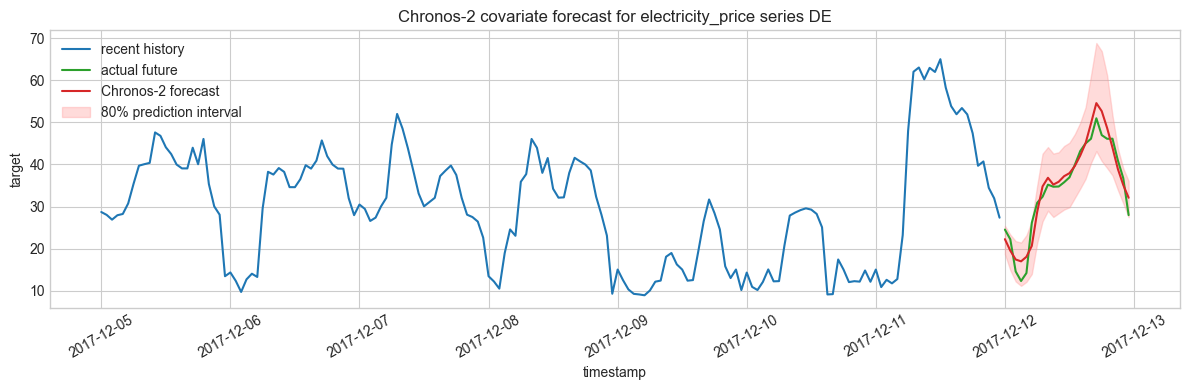

In [7]:
history_window = 7 * 24
history_df = context_df.tail(history_window)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(history_df[timestamp_column], history_df[target], label="recent history", color="#1f77b4")
ax.plot(comparison_df[timestamp_column], comparison_df["actual"], label="actual future", color="#2ca02c")
ax.plot(comparison_df[timestamp_column], comparison_df["predictions"], label="Chronos-2 forecast", color="#d62728")
ax.fill_between(
    comparison_df[timestamp_column],
    comparison_df["0.1"],
    comparison_df["0.9"],
    color="#ff9896",
    alpha=0.35,
    label="80% prediction interval",
)
ax.set_title(f"Chronos-2 covariate forecast for electricity_price series {example_item_id}")
ax.set_xlabel(timestamp_column)
ax.set_ylabel(target)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## What To Scale Next

Once this notebook runs successfully, the next repo steps for energy benchmarking are straightforward:

1. Expand from this single-series smoke test to multi-series long-format forecasting.
2. Add repeatable backtest windows instead of a single holdout horizon.
3. Compare Chronos-2 covariates against target-only Chronos runs on the same split.
4. Standardize runtime, memory, and accuracy reporting across notebook baselines.
